In [1]:
import numpy as np
from Bio.PDB import PDBParser
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr
from sklearn.manifold import MDS

import numpy as np
import matplotlib.pyplot as plt
import os
print(os.getpid())

743009


In [2]:
#option 1


import numpy as np
from Bio.PDB import PDBParser, Polypeptide
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize


# ---------------------------------------------------------------------
# 1) Reproduce the same filtered residue order as mapPDBToHMM
# ---------------------------------------------------------------------
def get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds):
    """
    Rebuilds the residue list in the same spirit/order as mapPDBToHMM.
    Assumes chainIds is a string like 'A' or 'AB'.
    """
    chainIds = list(chainIds)
    structure = PDBParser(QUIET=True).get_structure('void', pdbFile)

    chains = structure[0].get_chains()
    residues = [chain.get_list() for chain in chains if chain.id in chainIds]
    residues = [res for resList in residues for res in resList]

    filtered_residues = []
    filtered_seq = []

    for res in residues:
        if Polypeptide.is_aa(res, standard=True):
            try:
                aa = Polypeptide.protein_letters_3to1[res.get_resname()]
            except Exception:
                continue
            filtered_residues.append(res)
            filtered_seq.append(aa)

    if len(filtered_residues) == 0:
        raise ValueError(f"No standard amino-acid residues found on chains {chainIds}")

    return filtered_residues, ''.join(filtered_seq)


# ---------------------------------------------------------------------
# 2) Representative coordinate per residue
# ---------------------------------------------------------------------
def residue_rep_coord(res, distType='all'):
    """
    distType:
      - 'all'   -> centroid of all atoms in the residue
      - 'alpha' -> CA
      - 'beta'  -> CB, or CA for GLY
    """
    if distType == 'alpha':
        if "CA" in res:
            return res["CA"].get_coord()
        # fallback
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    if distType == 'beta':
        if res.get_resname() == 'GLY':
            if "CA" in res:
                return res["CA"].get_coord()
        else:
            if "CB" in res:
                return res["CB"].get_coord()
        # fallback
        if "CA" in res:
            return res["CA"].get_coord()
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    # distType == 'all'
    atoms = [a.get_coord() for a in res.get_atoms()]
    return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])


def extract_reference_coords_from_mi(pdbFile, chainIds, mi, distType='all'):
    """
    Builds an array of shape (len(mi), 3), with NaN for gaps/unmapped positions.
    Your code suggests:
      - mi == -1 => gap
      - positive values are 1-based residue indices in the filtered residue list
    """
    residues, seq = get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds)
    rep_coords = np.asarray([residue_rep_coord(res, distType=distType) for res in residues], dtype=float)

    mi = np.asarray(mi, dtype=int)
    coords_full = np.full((len(mi), 3), np.nan, dtype=float)

    valid = mi >= 1   # matches your current convention
    idx = mi[valid] - 1
    if np.any(idx < 0) or np.any(idx >= len(rep_coords)):
        raise ValueError("mi contains indices outside the filtered residue list.")

    coords_full[valid] = rep_coords[idx]
    return coords_full, residues, seq


# ---------------------------------------------------------------------
# 3) Classical MDS initialization
# ---------------------------------------------------------------------
def classical_mds(D, n_components=3):
    """
    Classical MDS for a complete distance matrix.
    """
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    D2 = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J

    evals, evecs = np.linalg.eigh(B)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    vals = np.maximum(evals[:n_components], 0.0)
    X = evecs[:, :n_components] * np.sqrt(vals)
    return X


def initial_fill_for_mds(D):
    """
    Fill missing distances for a good initial guess.
    """
    D = np.asarray(D, dtype=float)
    out = D.copy()

    finite = np.isfinite(out)
    finite_vals = out[finite & ~np.eye(out.shape[0], dtype=bool)]
    if finite_vals.size == 0:
        raise ValueError("No finite distances available for reconstruction.")

    fill_value = np.median(finite_vals) * 1.5
    out[~np.isfinite(out)] = fill_value
    out = 0.5 * (out + out.T)
    np.fill_diagonal(out, 0.0)
    return out


# ---------------------------------------------------------------------
# 4) Reconstruction by stress minimization over observed pairs
# ---------------------------------------------------------------------
def reconstruct_3d_from_partial_distance_matrix(D, random_state=0, maxiter=800):
    """
    Reconstruct coordinates from a distance matrix that may contain inf entries.
    We minimize stress only over finite pairs.

    Returns:
        X: (N,3) coordinates
        stress: final MSE over observed pairs
        success: optimizer success flag
    """
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    D0 = initial_fill_for_mds(D)
    X0 = classical_mds(D0, n_components=3)

    iu = np.triu_indices(n, k=1)
    obs = np.isfinite(D[iu])
    i_idx = iu[0][obs]
    j_idx = iu[1][obs]
    target = D[i_idx, j_idx]

    def objective(x_flat):
        X = x_flat.reshape(n, 3)
        d = np.linalg.norm(X[i_idx] - X[j_idx], axis=1)
        return np.mean((d - target) ** 2)

    res = minimize(
        objective,
        X0.ravel(),
        method='L-BFGS-B',
        options={'maxiter': maxiter, 'ftol': 1e-10}
    )

    X = res.x.reshape(n, 3)
    return X, float(res.fun), bool(res.success)


# ---------------------------------------------------------------------
# 5) Alignment and comparison to PDB coordinates
# ---------------------------------------------------------------------

def kabsch_align(P, Q):
    """
    Align P onto Q with optimal rotation after centering.
    Returns aligned P, centered Q, RMSD.
    """
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)

    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    C = Pc.T @ Qc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1.0, 1.0, d]) @ Wt

    P_aligned = Pc @ R
    rmsd_val = np.sqrt(np.mean(np.sum((P_aligned - Qc) ** 2, axis=1)))
    return P_aligned, Qc, rmsd_val

def best_alignment_with_mirror(P, Q):
    """
    Distance maps cannot distinguish mirror images.
    Try both orientations and keep the better one.
    """
    P1, Qc1, r1 = kabsch_align(P, Q)

    Pm = P.copy()
    Pm[:, 0] *= -1
    P2, Qc2, r2 = kabsch_align(Pm, Q)

    if r2 < r1:
        return P2, Qc2, r2, "mirrored"
    return P1, Qc1, r1, "normal"

#if i want scaling
def optimal_scaling(P, Q):
    """
    Find scalar s minimizing ||sP - Q||^2
    """
    num = np.sum(P * Q)
    den = np.sum(P * P)
    return num / den

def align_with_scaling(P, Q):
    """
    Align P onto Q with rotation + scaling
    """
    # center
    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    # rotation (Kabsch)
    C = Pc.T @ Qc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1, 1, d]) @ Wt

    P_rot = Pc @ R

    # scaling
    s = optimal_scaling(P_rot, Qc)
    P_scaled = s * P_rot

    rmsd = np.sqrt(np.mean(np.sum((P_scaled - Qc)**2, axis=1)))

    return P_scaled, Qc, rmsd, s


def best_alignment_with_scaling_and_mirror(P, Q):
    # normal
    P1, Qc1, r1, s1 = align_with_scaling(P, Q)

    # mirrored
    Pm = P.copy()
    Pm[:, 0] *= -1
    P2, Qc2, r2, s2 = align_with_scaling(Pm, Q)

    if r2 < r1:
        return P2, Qc2, r2, s2, "mirrored"
    else:
        return P1, Qc1, r1, s1, "normal"



def distance_metrics(D_true, D_pred):
    """
    Compare two complete distance matrices on the upper triangle.
    """
    iu = np.triu_indices_from(D_true, k=1)
    a = D_true[iu]
    b = D_pred[iu]

    mask = np.isfinite(a) & np.isfinite(b)
    a = a[mask]
    b = b[mask]

    pearson = np.corrcoef(a, b)[0, 1] if len(a) > 1 else np.nan
    mae = np.mean(np.abs(a - b)) if len(a) else np.nan
    rmse = np.sqrt(np.mean((a - b) ** 2)) if len(a) else np.nan

    return {"pearson": pearson, "mae": mae, "rmse": rmse}


# ---------------------------------------------------------------------
# 6) End-to-end pipeline
# ---------------------------------------------------------------------
def reconstruct_and_compare_with_mapPDBToHMM(dm, mi, pdbFile, chainIds, distType='all'):
    """
    dm: output distance map from mapPDBToHMM
    mi: mapping indexes from mapPDBToHMM
    distType: must match the way the map was constructed
    """
    dm = np.asarray(dm, dtype=float)
    mi = np.asarray(mi, dtype=int)

    # Use only residues that are mapped and have enough finite constraints
    valid = (mi >= 1) & (np.isfinite(dm).sum(axis=1) > 1)

    if valid.sum() < 4:
        raise ValueError("Too few mapped residues with finite distances to reconstruct 3D.")

    D_obs = dm[np.ix_(valid, valid)]

    # Reconstruct 3D from the observed map
    X_rec, stress, success = reconstruct_3d_from_partial_distance_matrix(D_obs)

    # Build PDB reference coordinates in the same order
    # For distType='all', centroid is the most reasonable comparison point.
    ref_coords_full, residues, seq = extract_reference_coords_from_mi(
        pdbFile, chainIds, mi, distType=distType
    )
    X_ref = ref_coords_full[valid]

    # Align reconstruction to the PDB reference
    X_aligned, X_ref_centered, coord_rmsd, scale, orientation = best_alignment_with_scaling_and_mirror(X_rec, X_ref)

    print("Scale factor:", scale)

    # Distance consistency of reconstructed 3D against observed dm
    D_rec = squareform(pdist(X_rec))
    dm_stats = distance_metrics(D_obs, D_rec)

    return {
        "X_rec": X_rec,
        "X_aligned": X_aligned,
        "X_ref_centered": X_ref_centered,
        "valid_mask": valid,
        "stress": stress,
        "optimizer_success": success,
        "coord_rmsd": coord_rmsd,
        "orientation": orientation,
        "distance_metrics": dm_stats,
        "D_obs": D_obs,
        "D_rec": D_rec,
    }

#plot

def plot_3d_overlay(X_ref, X_rec_aligned, title="3D comparison"):
    """
    X_ref: reference coordinates (from PDB, centered)
    X_rec_aligned: reconstructed coordinates aligned to reference
    """

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot PDB reference
    ax.plot(
        X_ref[:, 0], X_ref[:, 1], X_ref[:, 2],
        label="PDB",
        linewidth=2
    )

    # Plot reconstructed
    ax.plot(
        X_rec_aligned[:, 0], X_rec_aligned[:, 1], X_rec_aligned[:, 2],
        linestyle='--',
        label="Reconstruction",
        linewidth=2
    )

    # Optionally connect corresponding residues (helps visually)
    for i in range(len(X_ref)):
        ax.plot(
            [X_ref[i, 0], X_rec_aligned[i, 0]],
            [X_ref[i, 1], X_rec_aligned[i, 1]],
            [X_ref[i, 2], X_rec_aligned[i, 2]],
            alpha=0.2
        )

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_error_per_residue(X_ref, X_rec):
    errors = np.linalg.norm(X_ref - X_rec, axis=1)

    plt.figure(figsize=(7, 3))
    plt.plot(errors)
    plt.xlabel("Residue index")
    plt.ylabel("Distance error")
    plt.title("Per-residue reconstruction error")
    plt.tight_layout()
    plt.show()


def save_coords_as_pdb(coords, filename="reconstructed.pdb", chain_id="A"):
    """
    Save coordinates as a fake CA-only PDB for visualization.
    """
    with open(filename, "w") as f:
        for i, (x, y, z) in enumerate(coords, start=1):
            f.write(
                f"ATOM  {i:5d}  CA  ALA {chain_id}{i:4d}    "
                f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00           C\n"
            )
        f.write("END\n")

In [ ]:
#option2


import numpy as np
from Bio.PDB import PDBParser, Polypeptide
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize


# ---------------------------------------------------------------------
# 1) Reproduce the same filtered residue order as mapPDBToHMM
# ---------------------------------------------------------------------
def get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds):
    """
    Rebuilds the residue list in the same spirit/order as mapPDBToHMM.
    Assumes chainIds is a string like 'A' or 'AB'.
    """
    chainIds = list(chainIds)
    structure = PDBParser(QUIET=True).get_structure('void', pdbFile)

    chains = structure[0].get_chains()
    residues = [chain.get_list() for chain in chains if chain.id in chainIds]
    residues = [res for resList in residues for res in resList]

    filtered_residues = []
    filtered_seq = []

    for res in residues:
        if Polypeptide.is_aa(res, standard=True):
            try:
                aa = Polypeptide.protein_letters_3to1[res.get_resname()]
            except Exception:
                continue
            filtered_residues.append(res)
            filtered_seq.append(aa)

    if len(filtered_residues) == 0:
        raise ValueError(f"No standard amino-acid residues found on chains {chainIds}")

    return filtered_residues, ''.join(filtered_seq)


# ---------------------------------------------------------------------
# 2) Representative coordinate per residue
# ---------------------------------------------------------------------
def residue_rep_coord(res, distType='all'):
    """
    distType:
      - 'all'   -> centroid of all atoms in the residue
      - 'alpha' -> CA
      - 'beta'  -> CB, or CA for GLY
    """
    if distType == 'alpha':
        if "CA" in res:
            return res["CA"].get_coord()
        # fallback
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    if distType == 'beta':
        if res.get_resname() == 'GLY':
            if "CA" in res:
                return res["CA"].get_coord()
        else:
            if "CB" in res:
                return res["CB"].get_coord()
        # fallback
        if "CA" in res:
            return res["CA"].get_coord()
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    # distType == 'all'
    atoms = [a.get_coord() for a in res.get_atoms()]
    return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])


def extract_reference_coords_from_mi(pdbFile, chainIds, mi, distType='all'):
    """
    Builds an array of shape (len(mi), 3), with NaN for gaps/unmapped positions.
    Your code suggests:
      - mi == -1 => gap
      - positive values are 1-based residue indices in the filtered residue list
    """
    residues, seq = get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds)
    rep_coords = np.asarray([residue_rep_coord(res, distType=distType) for res in residues], dtype=float)

    mi = np.asarray(mi, dtype=int)
    coords_full = np.full((len(mi), 3), np.nan, dtype=float)

    valid = mi >= 1   # matches your current convention
    idx = mi[valid] - 1
    if np.any(idx < 0) or np.any(idx >= len(rep_coords)):
        raise ValueError("mi contains indices outside the filtered residue list.")

    coords_full[valid] = rep_coords[idx]
    return coords_full, residues, seq


#preprocess distance matrix 

def preprocess_distance_matrix(D, q=0.98):
    """
    Symmetrize, remove infinities, and clip extreme values.
    """
    D = np.asarray(D, dtype=float)
    D = 0.5 * (D + D.T)
    np.fill_diagonal(D, 0.0)

    finite = np.isfinite(D) & (D > 0)
    vals = D[finite]

    if vals.size == 0:
        raise ValueError("No finite distances in matrix.")

    fill_value = np.median(vals)
    upper = np.quantile(vals, q)

    D2 = D.copy()
    D2[~np.isfinite(D2)] = fill_value
    D2 = np.clip(D2, 0.0, upper)

    return D2



# ---------------------------------------------------------------------
# 3) Classical MDS initialization
# ---------------------------------------------------------------------
def classical_mds(D, n_components=3):
    """
    Classical MDS for a complete distance matrix.
    """
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    D2 = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J

    evals, evecs = np.linalg.eigh(B)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    vals = np.maximum(evals[:n_components], 0.0)
    X = evecs[:, :n_components] * np.sqrt(vals)
    return X



# ---------------------------------------------------------------------
# 4) Reconstruction by stress minimization over observed pairs
# ---------------------------------------------------------------------
def huber_loss(r, delta=1.0):
    """
    Robust loss for residuals.
    """
    a = np.abs(r)
    return np.where(a <= delta, 0.5 * r * r, delta * (a - 0.5 * delta))


def robust_reconstruct_3d(
    D,
    ignore_band=2,
    chain_lambda=0.1,
    smooth_lambda=0.02,  #maybe too strong
    n_restarts=10,
    maxiter=1000,
    random_state=0,
):
    """
    Reconstruct 3D coordinates from a noisy distance matrix.

    ignore_band:
        ignore pairs with |i-j| <= ignore_band in the distance fit
        and let the smoothness prior handle local geometry.

    chain_lambda:
        soft penalty on consecutive residues staying too far apart.

    smooth_lambda:
        soft penalty on curvature of the chain.

    Returns:
        best_X, best_stress
    """
    rng = np.random.default_rng(random_state)
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    # Fit only finite, nonlocal pairs
    iu = np.triu_indices(n, k=1)
    mask_finite = np.isfinite(D[iu])
    ii = iu[0][mask_finite]
    jj = iu[1][mask_finite]

    nonlocal_mask = np.abs(ii - jj) > ignore_band
    ii = ii[nonlocal_mask]
    jj = jj[nonlocal_mask]
    targets = D[ii, jj]

    if len(targets) < 3:
        raise ValueError("Too few usable distance constraints.")

    # Local chain target estimated from the matrix itself   mettere 3.8?
    chain_vals = [D[i, i + 1] for i in range(n - 1) if np.isfinite(D[i, i + 1])]
    if len(chain_vals) > 0:
        chain_target = float(np.median(chain_vals))
    else:
        chain_target = float(np.median(targets))

    # Initial guess from filled matrix
    D0 = preprocess_distance_matrix(D)
    X0 = classical_mds(D0)

    def objective(x_flat):
        X = x_flat.reshape(n, 3)

        # fit observed nonlocal distances
        d_obs = np.linalg.norm(X[ii] - X[jj], axis=1)
        resid = d_obs - targets
        stress_data = np.mean(huber_loss(resid, delta=1.0))

        # weak chain continuity prior
        if n > 1:
            d_chain = np.linalg.norm(X[1:] - X[:-1], axis=1)
            stress_chain = np.mean(huber_loss(d_chain - chain_target, delta=1.0))
        else:
            stress_chain = 0.0

        # smoothness prior: avoid jagged backbone
        if n > 2:
            second_diff = X[2:] - 2 * X[1:-1] + X[:-2]
            stress_smooth = np.mean(np.sum(second_diff ** 2, axis=1))
        else:
            stress_smooth = 0.0

        return stress_data + chain_lambda * stress_chain + smooth_lambda * stress_smooth

    best_X = None
    best_fun = np.inf

    for _ in range(n_restarts):
        x_init = X0 + 0.05 * rng.standard_normal(X0.shape)
        res = minimize(
            objective,
            x_init.ravel(),
            method="L-BFGS-B",
            options={"maxiter": maxiter, "ftol": 1e-10},
        )

        if res.fun < best_fun:
            best_fun = res.fun
            best_X = res.x.reshape(n, 3)

    return best_X, best_fun


# ---------------------------------------------------------------------
# 5) Alignment and comparison to PDB coordinates
# ---------------------------------------------------------------------

def kabsch_align(P, Q):
    """
    Align P onto Q with optimal rotation after centering.
    Returns aligned P, centered Q, RMSD.
    """
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)

    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    C = Pc.T @ Qc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1.0, 1.0, d]) @ Wt

    P_aligned = Pc @ R
    rmsd_val = np.sqrt(np.mean(np.sum((P_aligned - Qc) ** 2, axis=1)))
    return P_aligned, Qc, rmsd_val

def best_alignment_with_mirror(P, Q):
    """
    Distance maps cannot distinguish mirror images.
    Try both orientations and keep the better one.
    """
    P1, Qc1, r1 = kabsch_align(P, Q)

    Pm = P.copy()
    Pm[:, 0] *= -1
    P2, Qc2, r2 = kabsch_align(Pm, Q)

    if r2 < r1:
        return P2, Qc2, r2, "mirrored"
    return P1, Qc1, r1, "normal"

#if i want scaling
def optimal_scaling(P, Q):
    """
    Find scalar s minimizing ||sP - Q||^2
    """
    num = np.sum(P * Q)
    den = np.sum(P * P)
    return num / den

def align_with_scaling(P, Q):
    """
    Align P onto Q with rotation + scaling
    """
    # center
    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    # rotation (Kabsch)
    C = Pc.T @ Qc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1, 1, d]) @ Wt

    P_rot = Pc @ R

    # scaling
    s = optimal_scaling(P_rot, Qc)
    P_scaled = s * P_rot

    rmsd = np.sqrt(np.mean(np.sum((P_scaled - Qc)**2, axis=1)))

    return P_scaled, Qc, rmsd, s


def best_alignment_with_scaling_and_mirror(P, Q):
    # normal
    P1, Qc1, r1, s1 = align_with_scaling(P, Q)

    # mirrored
    Pm = P.copy()
    Pm[:, 0] *= -1
    P2, Qc2, r2, s2 = align_with_scaling(Pm, Q)

    if r2 < r1:
        return P2, Qc2, r2, s2, "mirrored"
    else:
        return P1, Qc1, r1, s1, "normal"



def distance_metrics(D_true, D_pred):
    """
    Compare two complete distance matrices on the upper triangle.
    """
    iu = np.triu_indices_from(D_true, k=1)
    a = D_true[iu]
    b = D_pred[iu]

    mask = np.isfinite(a) & np.isfinite(b)
    a = a[mask]
    b = b[mask]

    pearson = np.corrcoef(a, b)[0, 1] if len(a) > 1 else np.nan
    mae = np.mean(np.abs(a - b)) if len(a) else np.nan
    rmse = np.sqrt(np.mean((a - b) ** 2)) if len(a) else np.nan

    return {"pearson": pearson, "mae": mae, "rmse": rmse}


# ---------------------------------------------------------------------
# 6) End-to-end pipeline
# ---------------------------------------------------------------------
def reconstruct_and_compare_with_mapPDBToHMM(dm, mi, pdbFile, chainIds, distType='all'):
    """
    dm: output distance map from mapPDBToHMM
    mi: mapping indexes from mapPDBToHMM
    distType: must match the way the map was constructed
    """
    dm = np.asarray(dm, dtype=float)
    mi = np.asarray(mi, dtype=int)

    # Use only residues that are mapped and have enough finite constraints
    valid = (mi >= 1) & (np.isfinite(dm).sum(axis=1) > 1)

    if valid.sum() < 4:
        raise ValueError("Too few mapped residues with finite distances to reconstruct 3D.")

    D_obs = dm[np.ix_(valid, valid)]

    D_clean = preprocess_distance_matrix(D_obs)
    # Reconstruct 3D from the observed map
    X_rec, stress = robust_reconstruct_3d(
    D_clean,
    ignore_band=2,
    chain_lambda=0.1,
    smooth_lambda=0.02,
    n_restarts=20,
    maxiter=1500,
)
    # Build PDB reference coordinates in the same order
    # For distType='all', centroid is the most reasonable comparison point.
    ref_coords_full, residues, seq = extract_reference_coords_from_mi(
        pdbFile, chainIds, mi, distType=distType
    )
    X_ref = ref_coords_full[valid]

    # Align reconstruction to the PDB reference
    X_aligned, X_ref_centered, coord_rmsd, scale, orientation = best_alignment_with_scaling_and_mirror(X_rec, X_ref)

    print("Scale factor:", scale)

    # Distance consistency of reconstructed 3D against observed dm
    D_rec = squareform(pdist(X_rec))
    dm_stats = distance_metrics(D_obs, D_rec)

    return {
        "X_rec": X_rec,
        "X_aligned": X_aligned,
        "X_ref_centered": X_ref_centered,
        "valid_mask": valid,
        "stress": stress,
        "coord_rmsd": coord_rmsd,
        "orientation": orientation,
        "distance_metrics": dm_stats,
        "D_obs": D_obs,
        "D_rec": D_rec,
    }


#plot

def plot_3d_overlay(X_ref, X_rec_aligned, title="3D comparison"):
    """
    X_ref: reference coordinates (from PDB, centered)
    X_rec_aligned: reconstructed coordinates aligned to reference
    """

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot PDB reference
    ax.plot(
        X_ref[:, 0], X_ref[:, 1], X_ref[:, 2],
        label="PDB",
        linewidth=2
    )

    # Plot reconstructed
    ax.plot(
        X_rec_aligned[:, 0], X_rec_aligned[:, 1], X_rec_aligned[:, 2],
        linestyle='--',
        label="Reconstruction",
        linewidth=2
    )

    # Optionally connect corresponding residues (helps visually)
    for i in range(len(X_ref)):
        ax.plot(
            [X_ref[i, 0], X_rec_aligned[i, 0]],
            [X_ref[i, 1], X_rec_aligned[i, 1]],
            [X_ref[i, 2], X_rec_aligned[i, 2]],
            alpha=0.2
        )

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_error_per_residue(X_ref, X_rec):
    errors = np.linalg.norm(X_ref - X_rec, axis=1)

    plt.figure(figsize=(7, 3))
    plt.plot(errors)
    plt.xlabel("Residue index")
    plt.ylabel("Distance error")
    plt.title("Per-residue reconstruction error")
    plt.tight_layout()
    plt.show()


def save_coords_as_pdb(coords, filename="reconstructed.pdb", chain_id="A"):
    """
    Save coordinates as a fake CA-only PDB for visualization.
    """
    with open(filename, "w") as f:
        for i, (x, y, z) in enumerate(coords, start=1):
            f.write(
                f"ATOM  {i:5d}  CA  ALA {chain_id}{i:4d}    "
                f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00           C\n"
            )
        f.write("END\n")


In [13]:
#option3


import numpy as np
from Bio.PDB import PDBParser, Polypeptide
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize


# ---------------------------------------------------------------------
# 1) Reproduce the same filtered residue order as mapPDBToHMM
# ---------------------------------------------------------------------
def get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds):
    """
    Rebuilds the residue list in the same spirit/order as mapPDBToHMM.
    Assumes chainIds is a string like 'A' or 'AB'.
    """
    chainIds = list(chainIds)
    structure = PDBParser(QUIET=True).get_structure('void', pdbFile)

    chains = structure[0].get_chains()
    residues = [chain.get_list() for chain in chains if chain.id in chainIds]
    residues = [res for resList in residues for res in resList]

    filtered_residues = []
    filtered_seq = []

    for res in residues:
        if Polypeptide.is_aa(res, standard=True):
            try:
                aa = Polypeptide.protein_letters_3to1[res.get_resname()]
            except Exception:
                continue
            filtered_residues.append(res)
            filtered_seq.append(aa)

    if len(filtered_residues) == 0:
        raise ValueError(f"No standard amino-acid residues found on chains {chainIds}")

    return filtered_residues, ''.join(filtered_seq)


# ---------------------------------------------------------------------
# 2) Representative coordinate per residue
# ---------------------------------------------------------------------
def residue_rep_coord(res, distType='all'):
    """
    distType:
      - 'all'   -> centroid of all atoms in the residue
      - 'alpha' -> CA
      - 'beta'  -> CB, or CA for GLY
    """
    if distType == 'alpha':
        if "CA" in res:
            return res["CA"].get_coord()
        # fallback
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    if distType == 'beta':
        if res.get_resname() == 'GLY':
            if "CA" in res:
                return res["CA"].get_coord()
        else:
            if "CB" in res:
                return res["CB"].get_coord()
        # fallback
        if "CA" in res:
            return res["CA"].get_coord()
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    # distType == 'all'
    atoms = [a.get_coord() for a in res.get_atoms()]
    return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])


def extract_reference_coords_from_mi(pdbFile, chainIds, mi, distType='all'):
    """
    Builds an array of shape (len(mi), 3), with NaN for gaps/unmapped positions.
    Your code suggests:
      - mi == -1 => gap
      - positive values are 1-based residue indices in the filtered residue list
    """
    residues, seq = get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds)
    rep_coords = np.asarray([residue_rep_coord(res, distType=distType) for res in residues], dtype=float)

    mi = np.asarray(mi, dtype=int)
    coords_full = np.full((len(mi), 3), np.nan, dtype=float)

    valid = mi >= 1   # matches your current convention
    idx = mi[valid] - 1
    if np.any(idx < 0) or np.any(idx >= len(rep_coords)):
        raise ValueError("mi contains indices outside the filtered residue list.")

    coords_full[valid] = rep_coords[idx]
    return coords_full, residues, seq


#preprocess distance matrix 

def get_valid_mask(dm, mi, min_finite_per_row=1):
    dm = np.asarray(dm, dtype=float)
    mi = np.asarray(mi, dtype=int)

    # residue exists in the mapped structure
    mapped = mi >= 1

    # residue has enough finite distances to be useful
    enough_contacts = np.isfinite(dm).sum(axis=1) >= min_finite_per_row

    return mapped & enough_contacts



# def preprocess_distance_matrix(D, q=0.98):
#     """
#     Symmetrize, remove infinities, and clip extreme values.
#     """
#     D = np.asarray(D, dtype=float)
#     D = 0.5 * (D + D.T)
#     np.fill_diagonal(D, 0.0)

#     finite = np.isfinite(D) & (D > 0)
#     vals = D[finite]

#     if vals.size == 0:
#         raise ValueError("No finite distances in matrix.")

#     fill_value = np.median(vals)
#     upper = np.quantile(vals, q)

#     D2 = D.copy()
#     D2[~np.isfinite(D2)] = fill_value  #########invece che il gap mette un valore medio, non sono sicuro vada molto bene
#     D2 = np.clip(D2, 0.0, upper)

#     return D2



# ---------------------------------------------------------------------
# 3) Classical MDS initialization
# ---------------------------------------------------------------------
def classical_mds(D, n_components=3):
    """
    Classical MDS for a complete distance matrix.
    """
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    D2 = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J

    evals, evecs = np.linalg.eigh(B)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    vals = np.maximum(evals[:n_components], 0.0)
    X = evecs[:, :n_components] * np.sqrt(vals)
    return X



# ---------------------------------------------------------------------
# 4) Reconstruction by stress minimization over observed pairs
# ---------------------------------------------------------------------


def robust_reconstruct_3d_exact_bonds(
    D,
    valid_mask,
    bond_len=3.8,
    ignore_band=2,
    smooth_lambda=0.02,
    n_restarts=10,
    maxiter=1000,
    random_state=0,
):
    """
    Reconstruct 3D coordinates from a distance matrix while enforcing
    exact backbone bond length between consecutive REAL residues.

    Parameters
    ----------
    D : (N, N) array
        Full distance matrix. Gaps may be NaN/inf anywhere.
    valid_mask : (N,) boolean array
        True for real residues, False for gaps.
    bond_len : float
        Exact distance between consecutive residues in the compact chain.
    ignore_band : int
        Ignore pairs with |i-j| <= ignore_band in the distance fit.
        This is applied after removing gaps.
    smooth_lambda : float
        Weight of curvature regularization.
    n_restarts : int
        Number of random restarts.
    maxiter : int
        Max optimizer iterations.
    random_state : int
        RNG seed.

    Returns
    -------
    X_full : (N, 3) array
        Reconstructed coordinates with NaN at gaps.
    X_compact : (M, 3) array
        Coordinates for only the real residues.
    best_fun : float
        Final objective value.
    best_success : bool
        Optimizer success flag.
    valid_idx : (M,) array
        Indices of real residues in the original full array.
    """
    rng = np.random.default_rng(random_state)

    D = np.asarray(D, dtype=float)
    valid_mask = np.asarray(valid_mask, dtype=bool)

    if D.ndim != 2 or D.shape[0] != D.shape[1]:
        raise ValueError("D must be a square matrix.")
    if len(valid_mask) != D.shape[0]:
        raise ValueError("valid_mask must have the same length as D.shape[0].")

    # Keep only real residues
    valid_idx = np.flatnonzero(valid_mask)
    m = len(valid_idx)

    if m < 2:
        raise ValueError("Need at least 2 real residues to reconstruct a chain.")

    # Compact observed matrix
    D_obs = D[np.ix_(valid_idx, valid_idx)].copy()
    D_obs = 0.5 * (D_obs + D_obs.T)
    np.fill_diagonal(D_obs, 0.0)

    # Use only finite nonlocal pairs in the fit
    iu = np.triu_indices(m, k=1)
    ii, jj = iu
    targets = D_obs[ii, jj]

    keep = np.isfinite(targets) & (np.abs(ii - jj) > ignore_band)
    ii = ii[keep]
    jj = jj[keep]
    targets = targets[keep]

    if len(targets) < 3:
        raise ValueError("Too few usable distance constraints after filtering.")

    def huber_loss(r, delta=1.0):
        a = np.abs(r)
        return np.where(a <= delta, 0.5 * r * r, delta * (a - 0.5 * delta))

    def classical_mds(Dmat, n_components=3):
        Dmat = np.asarray(Dmat, dtype=float)
        n = Dmat.shape[0]
        D2 = Dmat ** 2
        J = np.eye(n) - np.ones((n, n)) / n
        B = -0.5 * J @ D2 @ J
        evals, evecs = np.linalg.eigh(B)
        idx = np.argsort(evals)[::-1]
        evals = evals[idx]
        evecs = evecs[:, idx]
        vals = np.maximum(evals[:n_components], 0.0)
        return evecs[:, :n_components] * np.sqrt(vals)

    def build_coords(params):
        """
        Params:
          - first 3 values: x0
          - remaining values: raw direction vectors for each bond
        Bond length is enforced exactly by normalization.
        """
        x0 = params[:3]

        if m == 1:
            return x0[None, :]

        U = params[3:].reshape(m - 1, 3)
        norms = np.linalg.norm(U, axis=1, keepdims=True)
        dirs = U / np.maximum(norms, 1e-12)   # unit directions
        steps = bond_len * dirs

        X = np.empty((m, 3), dtype=float)
        X[0] = x0
        X[1:] = x0 + np.cumsum(steps, axis=0)
        return X

    def objective(params):
        X = build_coords(params)

        # Fit observed distances
        d_obs = np.linalg.norm(X[ii] - X[jj], axis=1)
        resid = d_obs - targets
        stress_data = np.mean(huber_loss(resid, delta=1.0))

        # Optional smoothness prior
        if m > 2:
            second_diff = X[2:] - 2 * X[1:-1] + X[:-2]
            stress_smooth = np.mean(np.sum(second_diff ** 2, axis=1))
        else:
            stress_smooth = 0.0

        return stress_data + smooth_lambda * stress_smooth

    # Initial guess from MDS
    X0 = classical_mds(D_obs, n_components=3)
    if not np.all(np.isfinite(X0)) or np.allclose(X0, 0):
        X0 = rng.normal(size=(m, 3))

    if m == 1:
        base_params = X0[0].copy()
    else:
        diffs = np.diff(X0, axis=0)
        norms = np.linalg.norm(diffs, axis=1, keepdims=True)
        dirs0 = diffs / np.maximum(norms, 1e-12)
        U0 = dirs0 + 0.05 * rng.standard_normal(dirs0.shape)
        base_params = np.concatenate([X0[0], U0.ravel()])

    best_fun = np.inf
    best_X = None
    best_success = False

    for _ in range(n_restarts):
        p0 = base_params.copy()
        if m >= 1:
            p0[:3] += 0.2 * rng.standard_normal(3)
        if m > 1:
            p0[3:] += 0.2 * rng.standard_normal(p0[3:].shape)

        res = minimize(
            objective,
            p0,
            method="L-BFGS-B",
            options={"maxiter": maxiter, "ftol": 1e-10},
        )

        if res.fun < best_fun:
            best_fun = res.fun
            best_X = build_coords(res.x)
            best_success = res.success

    # Expand back to full length, with NaN at gaps
    X_full = np.full((D.shape[0], 3), np.nan, dtype=float)
    X_full[valid_idx] = best_X

    return X_full, best_X, best_fun, best_success, valid_idx


# ---------------------------------------------------------------------
# 5) Alignment and comparison to PDB coordinates
# ---------------------------------------------------------------------
#taking the pdb as the target, no gap
def extract_reference_coords_from_mi(pdbFile, chainIds, mi, distType='all'):
    residues, seq = get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds)
    rep_coords = np.asarray([residue_rep_coord(res, distType=distType) for res in residues], dtype=float)

    mi = np.asarray(mi, dtype=int)
    coords_full = np.full((len(mi), 3), np.nan, dtype=float)

    valid = mi >= 1
    idx = mi[valid] - 1

    if np.any(idx < 0) or np.any(idx >= len(rep_coords)):
        raise ValueError("mi contains indices outside the filtered residue list.")

    coords_full[valid] = rep_coords[idx]
    return coords_full, residues, seq



def kabsch_align(P, Q):
    """
    Align P onto Q with optimal rotation after centering.
    Returns aligned P, centered Q, RMSD.
    """
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)

    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    C = Pc.T @ Qc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1.0, 1.0, d]) @ Wt

    P_aligned = Pc @ R
    rmsd_val = np.sqrt(np.mean(np.sum((P_aligned - Qc) ** 2, axis=1)))
    return P_aligned, Qc, rmsd_val

def best_alignment_with_mirror(P, Q):
    """
    Distance maps cannot distinguish mirror images.
    Try both orientations and keep the better one.
    """
    P1, Qc1, r1 = kabsch_align(P, Q)

    Pm = P.copy()
    Pm[:, 0] *= -1
    P2, Qc2, r2 = kabsch_align(Pm, Q)

    if r2 < r1:
        return P2, Qc2, r2, "mirrored"
    return P1, Qc1, r1, "normal"




def distance_metrics(D_true, D_pred):
    """
    Compare two complete distance matrices on the upper triangle.
    """
    iu = np.triu_indices_from(D_true, k=1)
    a = D_true[iu]
    b = D_pred[iu]

    mask = np.isfinite(a) & np.isfinite(b)
    a = a[mask]
    b = b[mask]

    pearson = np.corrcoef(a, b)[0, 1] if len(a) > 1 else np.nan
    mae = np.mean(np.abs(a - b)) if len(a) else np.nan
    rmse = np.sqrt(np.mean((a - b) ** 2)) if len(a) else np.nan

    return {"pearson": pearson, "mae": mae, "rmse": rmse}


# ---------------------------------------------------------------------
# 6) End-to-end pipeline
# ---------------------------------------------------------------------
def reconstruct_and_compare_with_mapPDBToHMM(dm, mi, pdbFile, chainIds, distType='alpha'):
    """
    dm: output distance map from mapPDBToHMM
    mi: mapping indexes from mapPDBToHMM
    distType: must match the way the map was constructed
    """
    dm = np.asarray(dm, dtype=float)
    mi = np.asarray(mi, dtype=int)

    # residues that actually exist in the mapped structure
    valid = get_valid_mask(dm, mi, min_finite_per_row=1)

    if valid.sum() < 4:
        raise ValueError("Too few mapped residues with finite distances to reconstruct 3D.")

    D_obs = dm[np.ix_(valid, valid)]

    if np.isinf(D_obs).any() or np.isnan(D_obs).any():
        raise ValueError("Gap handling failed: D_obs must be fully finite after filtering.")


    X_full, X_rec, stress, success, valid_idx = robust_reconstruct_3d_exact_bonds(
        dm,
        valid_mask=valid,
        bond_len=3.8,
        ignore_band=2,
        smooth_lambda=0.02,
        n_restarts=20,
        maxiter=1500,
    )
    # Build PDB reference coordinates in the same order
    # For distType='all', centroid is the most reasonable comparison point.
    ref_coords_full, residues, seq = extract_reference_coords_from_mi(
        pdbFile, chainIds, mi, distType=distType
    )
    X_ref = ref_coords_full[valid]

    # Align reconstruction to the PDB reference
    X_aligned, X_ref_centered, coord_rmsd, orientation = best_alignment_with_mirror(X_rec, X_ref)
    

    # Distance consistency of reconstructed 3D against observed dm
    D_rec = squareform(pdist(X_rec))
    dm_stats = distance_metrics(D_obs, D_rec)

    return {
        "X_rec": X_rec,
        "X_aligned": X_aligned,
        "X_ref_centered": X_ref_centered,
        "valid_mask": valid,
        "stress": stress,
        "coord_rmsd": coord_rmsd,
        "orientation": orientation,
        "distance_metrics": dm_stats,
        "D_obs": D_obs,
        "D_rec": D_rec,
    }


#plot

def plot_3d_overlay_masked(X_ref_full, X_rec_full, valid_mask,
                           title="3D comparison", show_connections=True):
    """
    Plot only residues that exist in the reconstructed subset.

    Parameters:
    - X_ref_full: (N,3) reference coordinates (with gaps as NaN or unused)
    - X_rec_full: (M,3) reconstructed coordinates (already filtered OR same size)
    - valid_mask: (N,) boolean mask of valid residues
    """

    valid_mask = np.asarray(valid_mask, dtype=bool)

    # Extract only valid residues from reference
    X_ref = X_ref_full[valid_mask]

    # Handle two cases:
    # 1) X_rec already filtered (same size as X_ref)
    # 2) X_rec is full-size → filter it
    if X_rec_full.shape[0] == valid_mask.shape[0]:
        X_rec = X_rec_full[valid_mask]
    else:
        X_rec = X_rec_full

    if X_ref.shape != X_rec.shape:
        raise ValueError(f"Shape mismatch: ref {X_ref.shape}, rec {X_rec.shape}")

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot reference
    ax.plot(
        X_ref[:, 0], X_ref[:, 1], X_ref[:, 2],
        label="PDB (valid residues)",
        linewidth=2
    )

    # Plot reconstruction
    ax.plot(
        X_rec[:, 0], X_rec[:, 1], X_rec[:, 2],
        linestyle='--',
        label="Reconstruction",
        linewidth=2
    )

    # Optional: connect corresponding residues
    if show_connections:
        for i in range(len(X_ref)):
            ax.plot(
                [X_ref[i, 0], X_rec[i, 0]],
                [X_ref[i, 1], X_rec[i, 1]],
                [X_ref[i, 2], X_rec[i, 2]],
                alpha=0.2
            )

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_error_per_residue(X_ref, X_rec):
    errors = np.linalg.norm(X_ref - X_rec, axis=1)

    plt.figure(figsize=(7, 3))
    plt.plot(errors)
    plt.xlabel("Residue index")
    plt.ylabel("Distance error")
    plt.title("Per-residue reconstruction error")
    plt.tight_layout()
    plt.show()


def save_coords_as_pdb(coords, filename="reconstructed.pdb", chain_id="A"):
    """
    Save coordinates as a fake CA-only PDB for visualization.
    """
    with open(filename, "w") as f:
        for i, (x, y, z) in enumerate(coords, start=1):
            f.write(
                f"ATOM  {i:5d}  CA  ALA {chain_id}{i:4d}    "
                f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00           C\n"
            )

                # Write CONECT records (chain connectivity)
        for i in range(1, len(coords)):
            f.write(f"CONECT{i:5d}{i+1:5d}\n")
            f.write(f"CONECT{i+1:5d}{i:5d}\n")
            
        f.write("END\n")

In [3]:
#option 4


import numpy as np
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform


# ==========================================================
# Low-rank EDM reconstruction
# ==========================================================

def lowrank_edm_reconstruct(
    D,
    rank=3,
    mask=None,
    n_restarts=10,
    maxiter=1500,
    random_state=0,
):
    """
    Low-rank Euclidean Distance Matrix fitting.

    Solves:

        min_X sum_ij w_ij (||x_i-x_j||^2 - D_ij^2)^2

    where:
        X in R^{n x rank}

    Parameters
    ----------
    D : ndarray (n,n)
        Distance matrix.
    rank : int
        Embedding dimension.
    mask : ndarray (n,n) or None
        Binary mask for observed entries.
    n_restarts : int
        Number of random restarts.
    maxiter : int
        L-BFGS iterations.

    Returns
    -------
    X_best : ndarray (n, rank)
    best_loss : float
    """

    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    # Symmetrize
    D = 0.5 * (D + D.T)

    # Squared distances
    D2 = D ** 2

    # Observation mask
    if mask is None:
        W = np.isfinite(D).astype(float)
    else:
        W = mask.astype(float)

    np.fill_diagonal(W, 0.0)

    # Replace NaNs
    D2 = np.nan_to_num(D2, nan=0.0)

    best_loss = np.inf
    X_best = None

    def objective_and_grad(x_flat):
        X = x_flat.reshape(n, rank)

        diff = X[:, None, :] - X[None, :, :]
        dist2 = np.sum(diff**2, axis=2)

        R = W * (dist2 - D2)

        obj = 0.5 * np.sum(R**2)

        grad = np.zeros_like(X)

        for i in range(n):
            grad[i] = 4.0 * np.sum(
                R[i, :, None] * diff[i],
                axis=0
            )

        return obj, grad.ravel()

    rng = np.random.default_rng(random_state)

    for restart in range(n_restarts):

        X0 = 0.01 * rng.normal(size=(n, rank))

        result = minimize(
            fun=lambda x: objective_and_grad(x)[0],
            x0=X0.ravel(),
            jac=lambda x: objective_and_grad(x)[1],
            method="L-BFGS-B",
            options={
                "maxiter": maxiter,
                "ftol": 1e-12,
            },
        )

        if result.fun < best_loss:
            best_loss = result.fun
            X_best = result.x.reshape(n, rank)

    return X_best, best_loss


# ==========================================================
# Your pipeline
# ==========================================================

def reconstruct_and_compare_with_mapPDBToHMM(
    dm,
    mi,
    pdbFile,
    chainIds,
    distType='all'
):
    """
    dm: output distance map from mapPDBToHMM
    mi: mapping indexes from mapPDBToHMM
    distType: must match the way the map was constructed
    """

    dm = np.asarray(dm, dtype=float)
    mi = np.asarray(mi, dtype=int)

    # ======================================================
    # Keep only valid mapped residues
    # ======================================================

    valid = (
        (mi >= 1)
        & (np.isfinite(dm).sum(axis=1) > 1)
    )

    if valid.sum() < 4:
        raise ValueError(
            "Too few mapped residues with finite distances "
            "to reconstruct 3D."
        )

    D_obs = dm[np.ix_(valid, valid)]

    # ======================================================
    # Preprocess distance matrix
    # ======================================================

    D_clean = preprocess_distance_matrix(D_obs)

    # ======================================================
    # Build observation mask
    # ======================================================

    mask = np.isfinite(D_clean).astype(float)

    # Replace NaNs/infs
    D_clean = np.nan_to_num(D_clean, nan=0.0)

    # ======================================================
    # LOW-RANK EDM FITTING
    # ======================================================

    X_rec, stress = lowrank_edm_reconstruct(
        D_clean,
        rank=3,
        mask=mask,
        n_restarts=20,
        maxiter=1500,
    )

    # ======================================================
    # Build PDB reference coordinates
    # ======================================================

    ref_coords_full, residues, seq = \
        extract_reference_coords_from_mi(
            pdbFile,
            chainIds,
            mi,
            distType=distType
        )

    X_ref = ref_coords_full[valid]

    # ======================================================
    # Align reconstruction to reference
    # ======================================================

    X_aligned, X_ref_centered, coord_rmsd, scale, orientation = \
        best_alignment_with_scaling_and_mirror(
            X_rec,
            X_ref
        )

    print("Scale factor:", scale)

    # ======================================================
    # Distance consistency
    # ======================================================

    D_rec = squareform(pdist(X_rec))

    dm_stats = distance_metrics(
        D_obs,
        D_rec
    )

    return {
        "X_rec": X_rec,
        "X_aligned": X_aligned,
        "X_ref_centered": X_ref_centered,
        "valid_mask": valid,
        "stress": stress,
        "coord_rmsd": coord_rmsd,
        "orientation": orientation,
        "distance_metrics": dm_stats,
        "D_obs": D_obs,
        "D_rec": D_rec,
    }

In [18]:
from sequenceHandler import mapPDBToHMM
pfam_id= "PF00007"
pdb_file = f"PDB/{pfam_id}.pdb"
chain_id = "A"
hmm_file = f"HMM/{pfam_id}.hmm"
hmm_file_2 = "None"        
output_map_file = "None"  


dm, mi, aligned_sequence = mapPDBToHMM(pdb_file, chain_id, hmm_file, hmm_file_2, output_map_file, distType='alpha')
result = reconstruct_and_compare_with_mapPDBToHMM(dm, mi, pdb_file, chain_id, distType='alpha')
print(result["stress"], result["coord_rmsd"], result["distance_metrics"])

/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 1936.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 1987.
  warnings.warn(


Scale factor: 0.997770493212572
0.24513675610924512 3.447497617228934 {'pearson': np.float64(0.9993715513713485), 'mae': np.float64(0.30685861240935924), 'rmse': np.float64(0.4311694706032864)}


In [5]:
import matplotlib.pyplot as plt


def plot_3d_overlay(X_ref, X_rec_aligned, title="3D comparison"):
    """
    X_ref: reference coordinates (from PDB, centered)
    X_rec_aligned: reconstructed coordinates aligned to reference
    """

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot PDB reference
    ax.plot(
        X_ref[:, 0], X_ref[:, 1], X_ref[:, 2],
        label="PDB",
        linewidth=2
    )

    # Plot reconstructed
    ax.plot(
        X_rec_aligned[:, 0], X_rec_aligned[:, 1], X_rec_aligned[:, 2],
        linestyle='--',
        label="Reconstruction",
        linewidth=2
    )

    # Optionally connect corresponding residues (helps visually)
    for i in range(len(X_ref)):
        ax.plot(
            [X_ref[i, 0], X_rec_aligned[i, 0]],
            [X_ref[i, 1], X_rec_aligned[i, 1]],
            [X_ref[i, 2], X_rec_aligned[i, 2]],
            alpha=0.2
        )

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()



Scale factor: 0.997770493212572


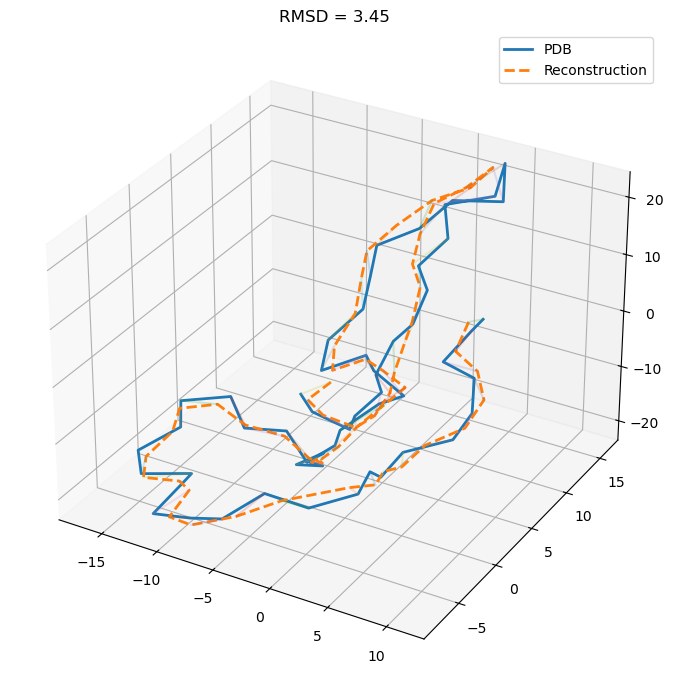

In [19]:
result = reconstruct_and_compare_with_mapPDBToHMM(
    dm, mi, pdb_file, chain_id, distType='alpha'
)

plot_3d_overlay(
    result["X_ref_centered"],
    result["X_aligned"],
    title=f"RMSD = {result['coord_rmsd']:.2f}"
)

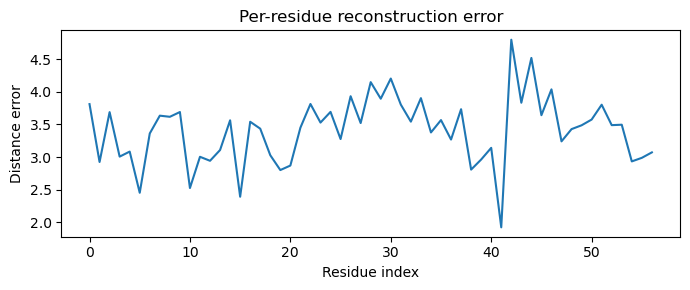

In [20]:
def plot_error_per_residue(X_ref, X_rec):
    errors = np.linalg.norm(X_ref - X_rec, axis=1)

    plt.figure(figsize=(7, 3))
    plt.plot(errors)
    plt.xlabel("Residue index")
    plt.ylabel("Distance error")
    plt.title("Per-residue reconstruction error")
    plt.tight_layout()
    plt.show()

plot_error_per_residue(
    result["X_ref_centered"],
    result["X_aligned"])

In [21]:
def save_coords_as_pdb(coords, filename="reconstructed.pdb", chain_id="A"):
    """
    Save coordinates as a fake CA-only PDB for visualization.
    """
    with open(filename, "w") as f:
        for i, (x, y, z) in enumerate(coords, start=1):
            f.write(
                f"ATOM  {i:5d}  CA  ALA {chain_id}{i:4d}    "
                f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00           C\n"
            )
        f.write("END\n")

# Save reconstructed (aligned)
save_coords_as_pdb(result["X_aligned"], "reconstructed.pdb")

# Save reference
save_coords_as_pdb(result["X_ref_centered"], "reference.pdb")

In [22]:
coords = np.array(result["X_ref_centered"])  # your first array
dists = np.linalg.norm(coords[1:] - coords[:-1], axis=1)
print(dists)

coords = np.array(result["X_aligned"])  # your second array
dists = np.linalg.norm(coords[1:] - coords[:-1], axis=1)
print(dists)

[ 3.7918743   3.82788463  3.78768128  3.76474737  3.75300838  3.73756537
  3.77147252  3.77016305  3.76833994 10.37108133  3.77426961  3.80668072
  3.83598641  3.80519529  3.82007977  3.82629571  3.80110829  3.82609596
  3.80228379  3.80783262  3.79267129  3.76623756  3.77200993  3.78301371
  3.76921882  3.79080482  3.76756436  3.76362712  3.83961895  3.7721492
  3.82413127  3.80835782  3.78839745  3.86495991  3.81203614  3.79703481
  3.83289102  3.88068748  3.79536016  3.80951384  3.8507534   3.76642431
  5.89689293  3.82915475  3.75232898  3.79259078  3.80309369  3.75059759
  3.76756674  3.80406159  3.82534575  3.78671876  3.76460601  3.7783966
  3.73408937  3.74502652]
[3.51972405 3.31075575 3.49682101 3.65797991 3.37989315 3.58120912
 3.35409263 3.66089686 3.71290389 6.98887492 3.73147171 3.61593169
 2.4400934  3.15242221 2.92053043 2.96353686 3.02867312 3.09306133
 3.52386659 2.90545053 3.32166227 3.69376999 3.14583104 3.36920355
 3.2703925  3.68799721 3.02191656 3.64181955 3.6373